# 1. Environment Setup

Import all necessary libraries including pandas, numpy, scikit-learn for data processing, machine learning, and visualization. Set random seeds for reproducibility.

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler

# Đặt seed để đảm bảo nhất quán giữa các lần chạy
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


# 2. Data Processing

## 2.0 Dataset

### Overview
The Cleveland Heart Disease dataset contains 14 clinical features used to predict the presence of heart disease in patients. These are standard measurements taken during cardiac health assessments.<br>
Source: https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland
### Feature Descriptions

| Feature | Description |
|---------|-------------|
| **age** | Age in years |
| **sex** | Sex (1 = male; 0 = female) |
| **cp** | Chest pain type: 1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic |
| **trestbps** | Resting blood pressure (mm Hg on hospital admission) |
| **chol** | Serum cholesterol in mg/dL |
| **fbs** | Fasting blood sugar > 120 mg/dL (1 = true; 0 = false) |
| **restecg** | Resting electrocardiographic results: 0 = normal; 1 = ST-T wave abnormality; 2 = probable/definite left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved |
| **exang** | Exercise-induced angina (1 = yes; 0 = no) |
| **oldpeak** | ST depression induced by exercise relative to rest |
| **slope** | The slope of the peak exercise ST segment: 1 = upsloping; 2 = flat; 3 = downsloping |
| **ca** | Number of major vessels (0-3) colored by fluoroscopy |
| **thal** | Thalassemia: 3 = normal; 6 = fixed defect; 7 = reversible defect |
| **target** | Diagnosis of heart disease: 0 = no disease; 1 = disease present |

### Summary
These 13 features are clinical measurements commonly used by cardiologists to assess heart disease risk. The combination of demographic, symptom-related, and test-based features enables comprehensive cardiac health assessment for predictive modeling.

## 2.1 Data Processing 

Download the Cleveland heart disease dataset from Google Drive.

In [2]:
!gdown 16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju

Downloading...
From: https://drive.google.com/uc?id=16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju
To: /content/cleveland.csv
100% 10.9k/10.9k [00:00<00:00, 28.4MB/s]


Load and preview the raw data to understand its structure.

In [3]:
test=pd.read_csv("cleveland.csv")
test.head(10)

,63,1,1.1,145,233,1.2,2,150,0,2.3,3,0.1,6,0.2
0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
6,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
8,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1
9,57,1,4,140,192,0,0,148,0,0.4,2,0.0,6.0,0


Assign column names to the dataset and convert the target variable to binary (0 or 1) where 1 indicates presence of heart disease.

In [4]:
COLUMNS = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 
    'ca', 'thal', 'target'
]
PATH="cleveland.csv"
raw_df = pd.read_csv(PATH, names=COLUMNS)
raw_df["target"] = raw_df["target"].apply(lambda x: 1 if x > 0 else 0)
raw_df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


Separate features into numeric and categorical columns for appropriate preprocessing.

In [5]:
FEATURES=[col for col in raw_df.columns if col != "target"]
numeric_cols=[]
categorical_cols=[]
for col in FEATURES:
    unique_col=raw_df[col].nunique()
    if unique_col>10:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


# 3. EDA

## 3.0 Target Quick Check 

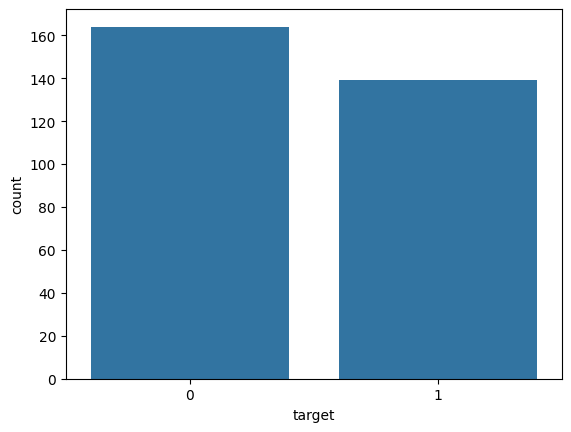

In [6]:
# Create countplot
ax = sns.countplot(x='target', data=raw_df)


### Key Insights
✅ **Well-Balanced Dataset** - The classes are nearly evenly distributed, indicating minimal class imbalance.

✅ **Model Training Advantage** - With balanced classes, we can train ML models without special handling techniques like oversampling, undersampling, or class weight adjustments.

✅ **Fair Evaluation** - The balanced distribution ensures that accuracy and other metrics will be meaningful without being skewed by class prevalence.

## 3.1 Numeric Features

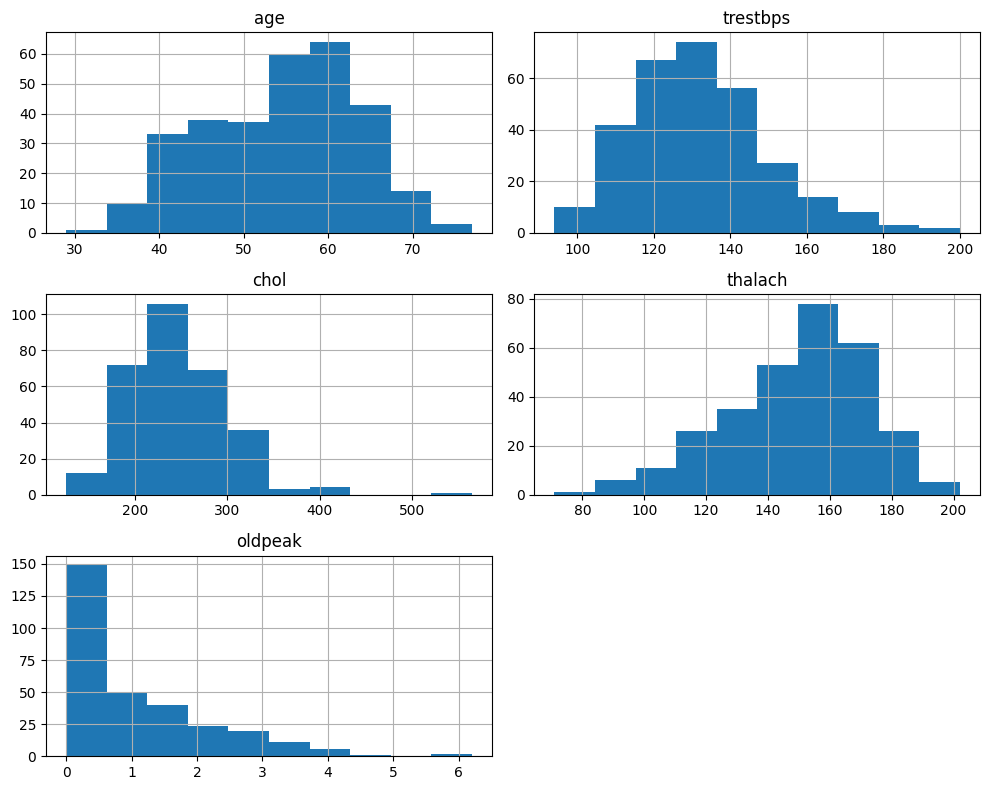

In [7]:
# Plot histograms for numerical columns
raw_df[numeric_cols].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

### Insights:
* **Age** - Normal distribution, peaks at 55-60 years (middle-aged/older adults)
* **Trestbps** - Normal distribution, centered around 120-130 mm Hg
* **Chol** - Right-skewed with outliers, peaks at 200-250 mg/dL
* **thalach** - thalach appears approximately normally distributed, with a bell-shaped pattern centered around 150–165.
* **Oldpeak** - Heavily right-skewed with >140 patients at 0 (healthy), outliers suggest disease


## 3.2 Categorical Features

In [ ]:
def plot_categorical_distribution(df, col):
    plt.figure(figsize=(6, 6))
    df.groupby([col, 'target']).size().unstack().plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'Distribution of Target by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Target', loc='upper right')
    plt.xticks(rotation=0)
    plt.show()

### 1. Gender

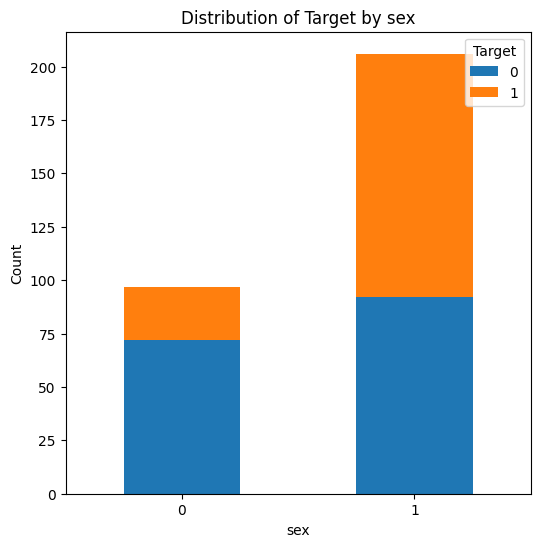

In [9]:
plot_categorical_distribution(raw_df, "sex")

**Insights**:


* Males (sex=1) have a much larger count overall and also more cases with heart disease.
* Females (sex=0) show fewer total patients and fewer heart disease cases.
* This suggests the dataset has more male samples and that heart disease appears more frequently among males in this sample.

### 2. CP

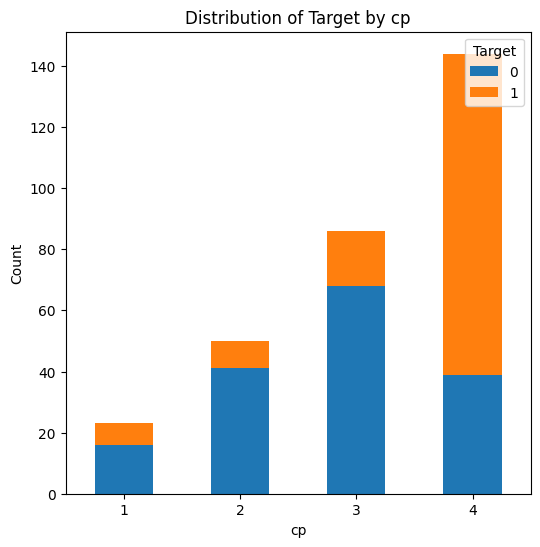

In [10]:
plot_categorical_distribution(raw_df, "cp")

**Insights**: 
* This suggests chest pain type 4 is most strongly associated with heart disease in this dataset.
* CP might be the moderate and informative seperator

### 3. fbs

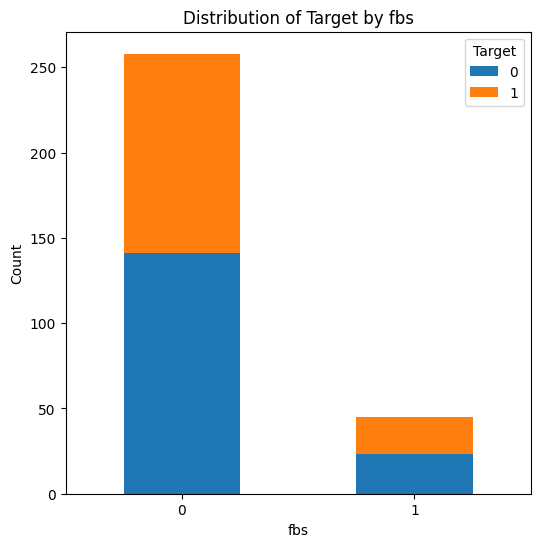

In [11]:
plot_categorical_distribution(raw_df, "fbs")

**Insights:** This suggests high fasting blood sugar is rare in this dataset and not by itself a strong separator of heart disease status.

### 4. restecg

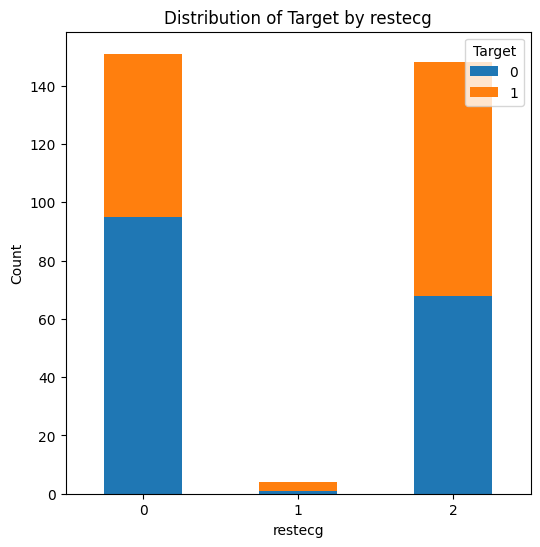

In [12]:
plot_categorical_distribution(raw_df, "restecg")

**Insights**:
* restecg=0 and restecg=2 are the dominant groups, with similar total counts.
* restecg=1 is very rare in this dataset
* This suggests that restecg=2 are more often associated with heart disease here.

### 5. exang

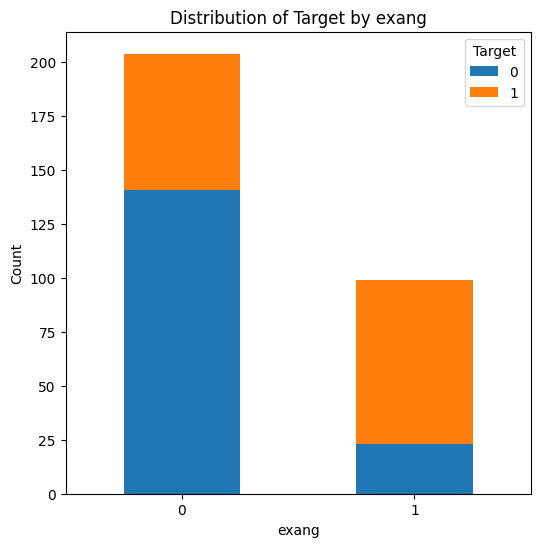

In [13]:
plot_categorical_distribution(raw_df, "exang")

**Insights**: 
* exang=0 is the dominant group and this group contains the majority of both diseased and undiseased cases
* exang=1 is smaller but has a much higher proportion of heart disease cases compare to non-disease
* This suggests that exang=1 is rare but when present it is more likely to get disease.

### 6. slope

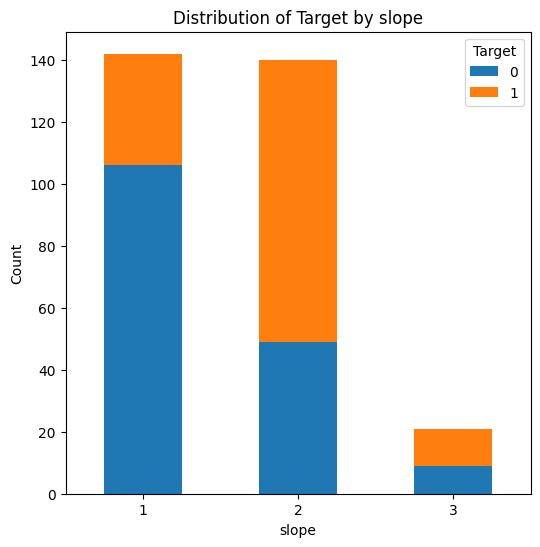

In [14]:
plot_categorical_distribution(raw_df, "slope")

**Insights:** This indicates a flat ST segment slope (**slope=2**) is most associated with heart disease in this dataset.

### 7. ca

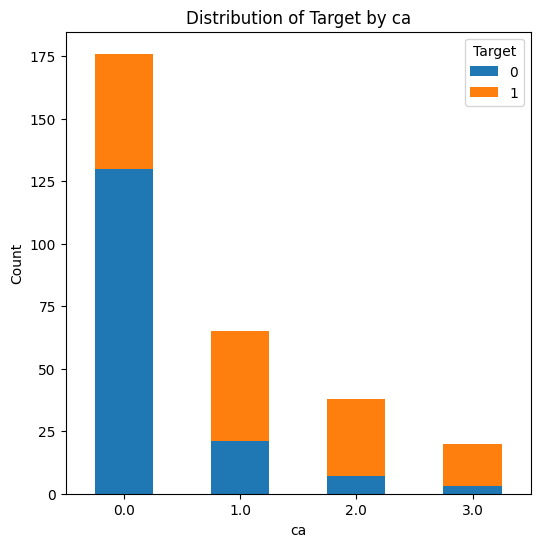

In [15]:
plot_categorical_distribution(raw_df, "ca")

**Insights:** As ca increases from 1 to 3, the share of heart disease rises sharply.

### 8. thal

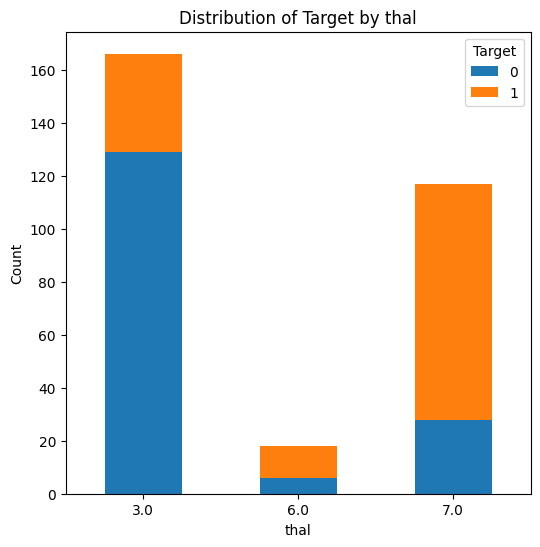

In [16]:
plot_categorical_distribution(raw_df, "thal")

**Insights:**
* thal=3 is the most common group and mostly no-disease patients.
* thal=7 has many more heart disease cases than non-disease cases.
* thal=6 is rare but still shows more disease than non-disease.
* This suggests that thal=7 are strongly associated with heart disease in this dataset.

## 3.3 Correlation Matrix

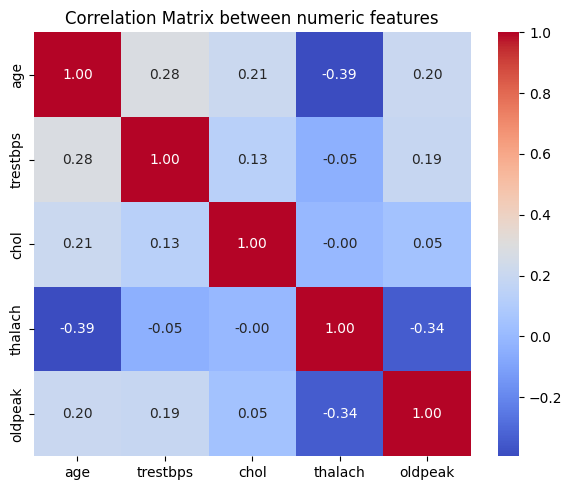

In [17]:
plt.figure(figsize=(6, 5))
corr_matrix = raw_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix between numeric features")
plt.tight_layout()
plt.show()

### **Insights:**
- The strongest relationships are negative:
  - `age` vs `thalach` (~ -0.39): older patients tend to have lower maximum heart rate.
  - `thalach` vs `oldpeak` (~ -0.34): higher max heart rate is associated with lower ST depression.

## 3.4 Pairwise Distribution

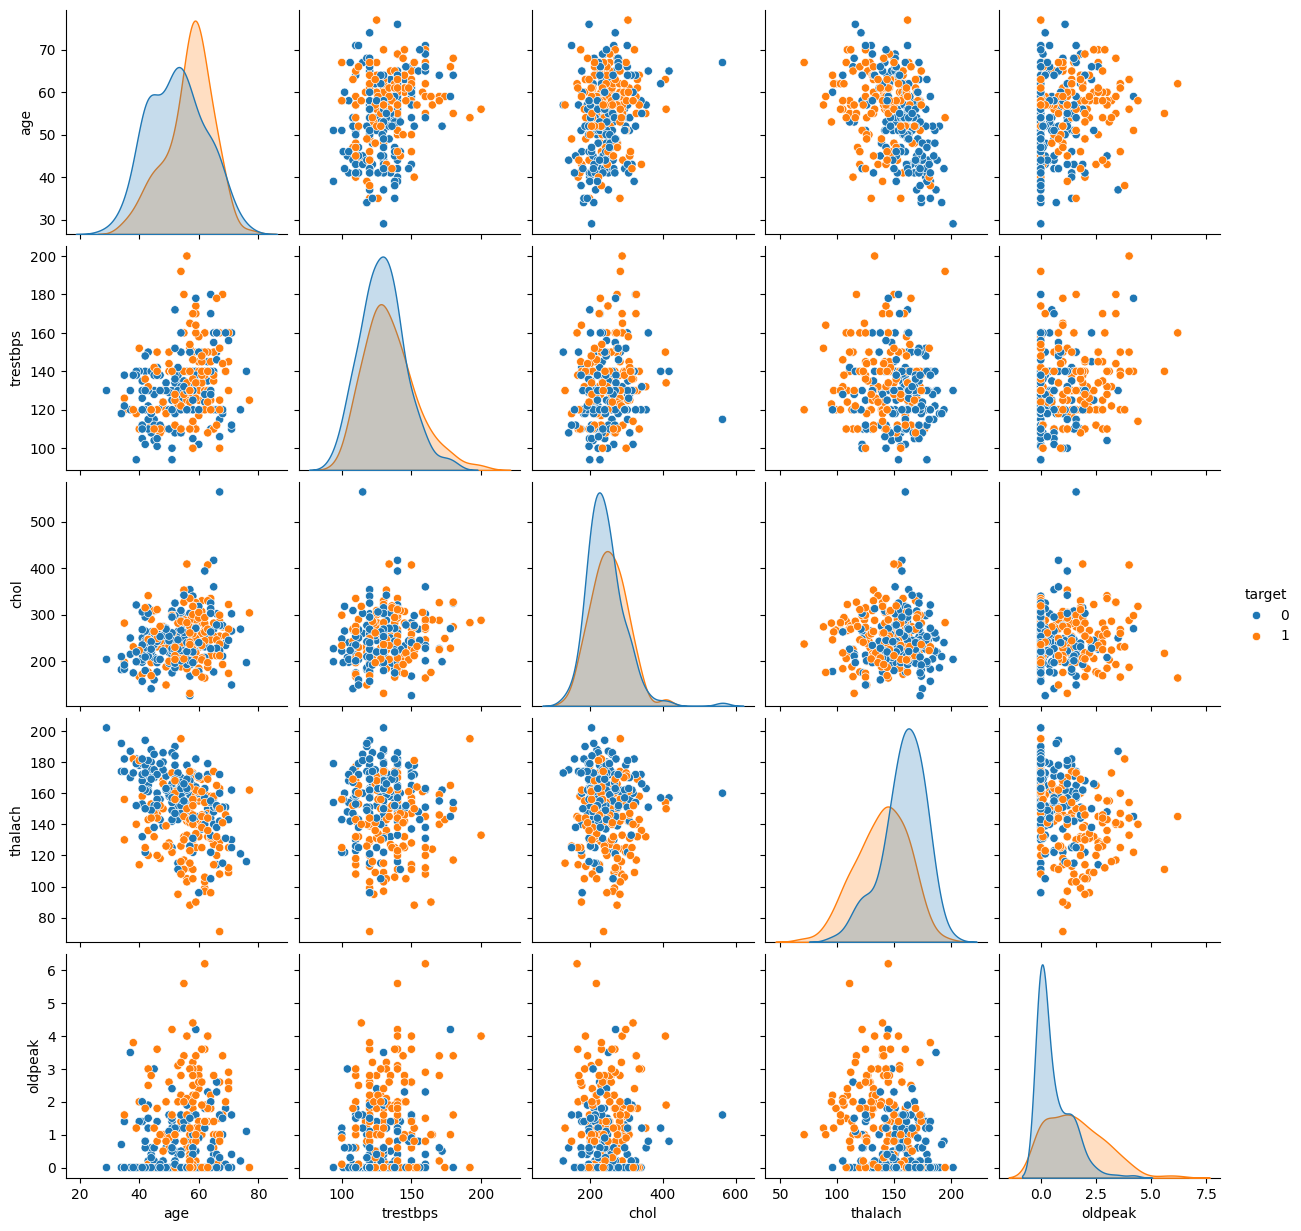

<Figure size 1000x1000 with 0 Axes>

In [18]:
sns.pairplot(raw_df, vars=numeric_cols, hue="target", diag_kind="kde")
plt.figure(figsize=(10, 10))
plt.suptitle("Pairwise Distribution between numeric features by targets", y=1.02)
plt.savefig("pairwise_distribution.pdf", bbox_inches="tight")
plt.show()

### **Insights**:
- **`thalach`** shows the clearest class separation among the numeric features.  
  Patients with `target = 1` tend to have **lower maximum heart rate (`thalach`)**, while patients with `target = 0` are more concentrated at **higher `thalach` values**.

- **`oldpeak`** is also strongly associated with the target.**  
  The `target = 1` group is shifted toward **higher `oldpeak` values**, suggesting that higher ST depression is more common among patients with heart disease.

- **`age`** provides moderate signal, but the separation is weaker than for `thalach` and `oldpeak`.  
  The `target = 1` distribution appears slightly shifted toward **older ages**, although the overlap between classes remains substantial.

- **`chol` and `tretbps`** appear to be the least informative numeric feature in this plot. 
  The distributions of `chol` and `tretbps`terol for the two classes are highly overlapping, suggesting weak standalone predictive power.

- A negative relationship between `age` and `thalach` is clearly visible which is similar to what correlation matrix has shown.

- A negative relationship between `oldpeak` and `thalach` is clearly visible which is similar to what correlation matrix has shown.

- Most numeric features do not separate the classes well on their own. 
  The scatter plots show considerable overlap between `target = 0` and `target = 1`, suggesting that the model will likely benefit from **combining multiple features** rather than relying on a single variable.<br>
  => Feature engineering may be useful, especially for **age-related interactions**.


## 3.5 Age-related interactions 

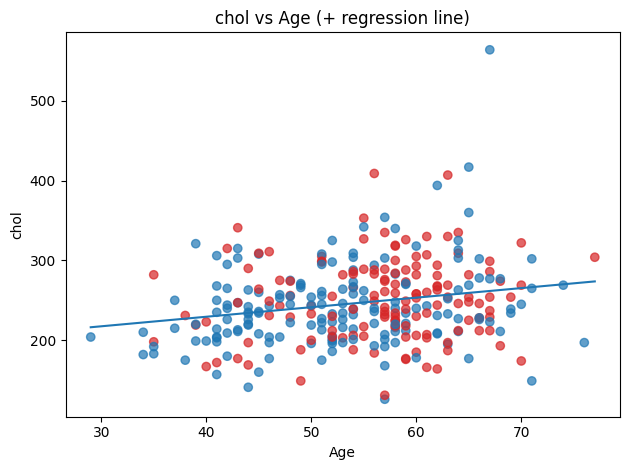

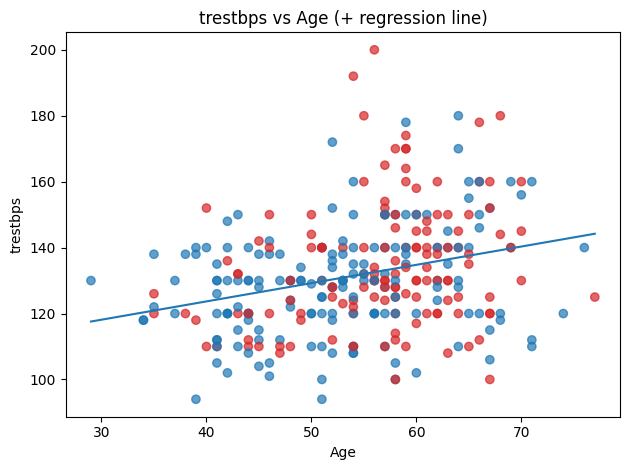

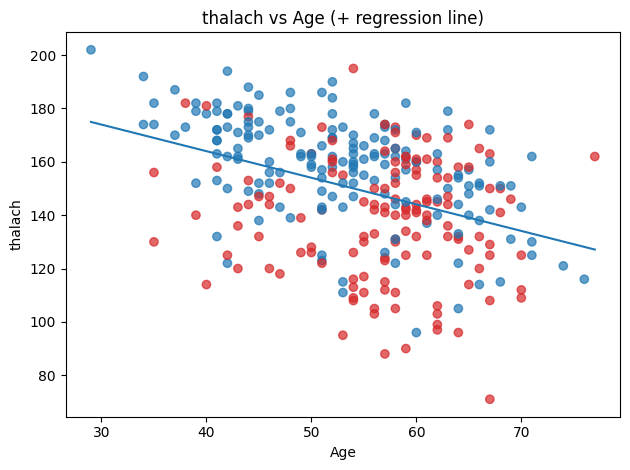

In [20]:
X = raw_df.drop(columns=['target'])
y = raw_df['target']

# Colors by target
colors = ['tab:blue' if t==0 else 'tab:red' for t in y]

def scatter_with_regression(x_series, y_series, x_label, y_label, title):
    # Drop NaNs for fitting
    m = x_series.notna() & y_series.notna()
    x = x_series[m].values.reshape(-1, 1)
    yy = y_series[m].values
    # Fit linear regression
    if len(x) > 1:
        model = LinearRegression()
        model.fit(x, yy)
        # Create line
        x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
        y_pred = model.predict(x_line)
    else:
        x_line, y_pred = None, None

    # Plot scatter
    plt.figure()
    plt.scatter(x_series, y_series, c=colors, alpha=0.7)
    plt.xlabel(x_label); plt.ylabel(y_label)
    plt.title(title)

    # Plot regression line
    if x_line is not None:
        plt.plot(x_line.ravel(), y_pred)
    plt.tight_layout()
    plt.show()
# Scatter + regression for selected pairs
if 'age' in X.columns:
    for col in ['chol', 'trestbps', 'thalach']:
        if col in X.columns:
            scatter_with_regression(X['age'], X[col], 'Age', col, f'{col} vs Age (+ regression line)')

# 4. Some questions ?

### 1. Which features are most strongly associated with heart disease status?
Based on the EDA, the features most strongly associated with `target = 1` (heart disease present) are:
- **`thalach`**: The strongest numeric separator. Patients with heart disease tend to have **lower maximum heart rate**.
- **`oldpeak`**: Strongly associated with the target. Patients with heart disease tend to have **higher ST depression**.
- **`cp`**: **Chest pain type = 4** appears most associated with heart disease.
- **`exang`**: Patients with **exercise-induced angina (`exang = 1`)** have a higher proportion of heart disease.
- **`slope`**: A **flat ST segment (`slope = 2`)** is most associated with heart disease.
- **`thal`**: **`thal = 7`** is strongly associated with heart disease.

### 2. What feature relationships suggest useful feature engineering opportunities?
- A negative relationship between `age` and `thalach` shows the most informative interactions. 
- `thalach` and `oldpeak` also show a noticeable negative relationship.

### 3. Which features appear weak individually but may become useful when combined with others?
**Weak-alone features:**
- `chol`
- `trestbps`
- `fbs`
